# 🌍 Customer Intelligence System
## End-to-End Country Profiling using Classification, Ensemble Learning & Clustering

## 📦 Step 1 – Import Libraries

In [3]:
import warnings
warnings.filterwarnings('ignore')

# Core data science
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Sklearn – preprocessing & decomposition
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Sklearn – clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors

# Sklearn – classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               VotingClassifier)
from sklearn.linear_model import LogisticRegression

# XGBoost
from xgboost import XGBClassifier

# Sklearn – evaluation & model selection
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      StratifiedKFold, cross_val_score)
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, silhouette_score,
                              davies_bouldin_score, calinski_harabasz_score,
                              roc_auc_score)

# Style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

print("✅ All libraries imported successfully!")
print(f"NumPy: {np.__version__}  |  Pandas: {pd.__version__}")


✅ All libraries imported successfully!
NumPy: 1.26.4  |  Pandas: 2.2.2


## 📂 Step 2 – Data Loading

In [5]:
import os

def generate_country_dataset():
    """
    Generates a realistic synthetic version of the Country-data dataset.
    Statistical distributions are calibrated to match the original Kaggle dataset
    (167 countries, 9 socio-economic/health features).
    """
    np.random.seed(42)

    countries = [
        'Afghanistan','Albania','Algeria','Angola','Antigua and Barbuda',
        'Argentina','Armenia','Australia','Austria','Azerbaijan',
        'Bahamas','Bahrain','Bangladesh','Barbados','Belarus','Belgium',
        'Belize','Benin','Bhutan','Bolivia','Bosnia and Herzegovina',
        'Botswana','Brazil','Burkina Faso','Burundi','Cambodia','Cameroon',
        'Canada','Cape Verde','Central African Republic','Chad','Chile',
        'China','Colombia','Comoros','Congo Dem Rep','Congo Rep',
        'Costa Rica','Cote dIvoire','Croatia','Cuba','Czech Republic',
        'Denmark','Djibouti','Dominican Republic','Ecuador','Egypt',
        'El Salvador','Equatorial Guinea','Eritrea','Estonia','Ethiopia',
        'Fiji','Finland','France','Gabon','Gambia','Georgia','Germany',
        'Ghana','Greece','Guatemala','Guinea','Guinea-Bissau','Guyana',
        'Haiti','Honduras','Hungary','India','Indonesia','Iran','Iraq',
        'Ireland','Israel','Italy','Jamaica','Japan','Jordan','Kazakhstan',
        'Kenya','Korea Rep','Kuwait','Kyrgyz Republic','Laos','Latvia',
        'Lebanon','Lesotho','Liberia','Libya','Lithuania','Macedonia',
        'Madagascar','Malawi','Malaysia','Maldives','Mali','Malta',
        'Mauritania','Mauritius','Mexico','Moldova','Mongolia','Montenegro',
        'Morocco','Mozambique','Myanmar','Namibia','Nepal','Netherlands',
        'New Zealand','Nicaragua','Niger','Nigeria','Norway','Oman',
        'Pakistan','Panama','Papua New Guinea','Paraguay','Peru',
        'Philippines','Poland','Portugal','Romania','Russia','Rwanda',
        'Saudi Arabia','Senegal','Sierra Leone','Singapore','Slovak Republic',
        'Slovenia','Solomon Islands','Somalia','South Africa','Spain',
        'Sri Lanka','Sudan','Suriname','Swaziland','Sweden','Switzerland',
        'Syria','Tanzania','Thailand','Timor-Leste','Togo',
        'Trinidad and Tobago','Tunisia','Turkey','Uganda','Ukraine',
        'United Arab Emirates','United Kingdom','United States','Uruguay',
        'Uzbekistan','Venezuela','Vietnam','Yemen','Zambia','Zimbabwe'
    ]
    n = len(countries)  # 162 countries

    # Assign development tier (drives correlated features)
    tiers = np.array([0]*45 + [1]*75 + [2]*42)[:n]

    gdpp       = np.where(tiers==0, np.random.uniform(200, 1500, n),
                 np.where(tiers==1, np.random.uniform(1500, 15000, n),
                                    np.random.uniform(15000, 75000, n)))

    child_mort = np.where(tiers==0, np.random.uniform(60, 160, n),
                 np.where(tiers==1, np.random.uniform(10, 65, n),
                                    np.random.uniform(2, 12, n)))

    life_expec = np.where(tiers==0, np.random.uniform(45, 65, n),
                 np.where(tiers==1, np.random.uniform(62, 76, n),
                                    np.random.uniform(74, 85, n)))

    income     = gdpp * np.random.uniform(0.85, 1.35, n)

    total_fer  = np.where(tiers==0, np.random.uniform(4.0, 7.5, n),
                 np.where(tiers==1, np.random.uniform(1.8, 4.5, n),
                                    np.random.uniform(1.2, 2.2, n)))

    inflation  = np.where(tiers==0, np.random.uniform(8, 30, n),
                 np.where(tiers==1, np.random.uniform(3, 12, n),
                                    np.random.uniform(0.5, 5, n)))

    health     = np.where(tiers==0, np.random.uniform(2, 6, n),
                 np.where(tiers==1, np.random.uniform(4, 9, n),
                                    np.random.uniform(7, 14, n)))

    exports    = np.random.uniform(5, 80, n)
    imports    = exports * np.random.uniform(0.5, 1.8, n)

    df = pd.DataFrame({
        'country':    countries[:n],
        'child_mort': np.round(child_mort, 2),
        'exports':    np.round(exports,    2),
        'health':     np.round(health,     2),
        'imports':    np.round(imports,    2),
        'income':     np.round(income).astype(int),
        'inflation':  np.round(inflation,  2),
        'life_expec': np.round(life_expec, 2),
        'total_fer':  np.round(total_fer,  2),
        'gdpp':       np.round(gdpp).astype(int),
    })
    return df


# Try loading from disk first; fall back to synthetic generation
DATA_PATH = 'Country-data.csv'
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"✅ Loaded from disk: {DATA_PATH}")
else:
    df = generate_country_dataset()
    df.to_csv(DATA_PATH, index=False)
    print("ℹ️  Kaggle file not found. Synthetic dataset generated & saved.")

print(f"\nDataset shape: {df.shape}")
print(f"Rows (countries): {df.shape[0]}  |  Columns (features): {df.shape[1]}")
df.head(8)


✅ Loaded from disk: Country-data.csv

Dataset shape: (167, 10)
Rows (countries): 167  |  Columns (features): 10


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.90,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.77,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.16,82.0,1.93,51900


## 🔍 Step 3 – Exploratory Data Analysis (EDA)

In [7]:
# ── 3.1 Basic info ──────────────────────────────────────────
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(df.info())


DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None


In [8]:
# ── 3.2 Descriptive statistics ──────────────────────────────
print("\n📊 Descriptive Statistics:")
df.describe().T.style.background_gradient(cmap='Blues').format(precision=2)



📊 Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
child_mort,167.00,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.00,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.00,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.00,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.00,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.00,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.00,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.00,2.95,1.51,1.15,1.79,2.41,3.88,7.49
gdpp,167.00,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


In [9]:
# ── 3.3 Missing values ──────────────────────────────────────
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "✅ No missing values found!")


Missing values per column:
✅ No missing values found!


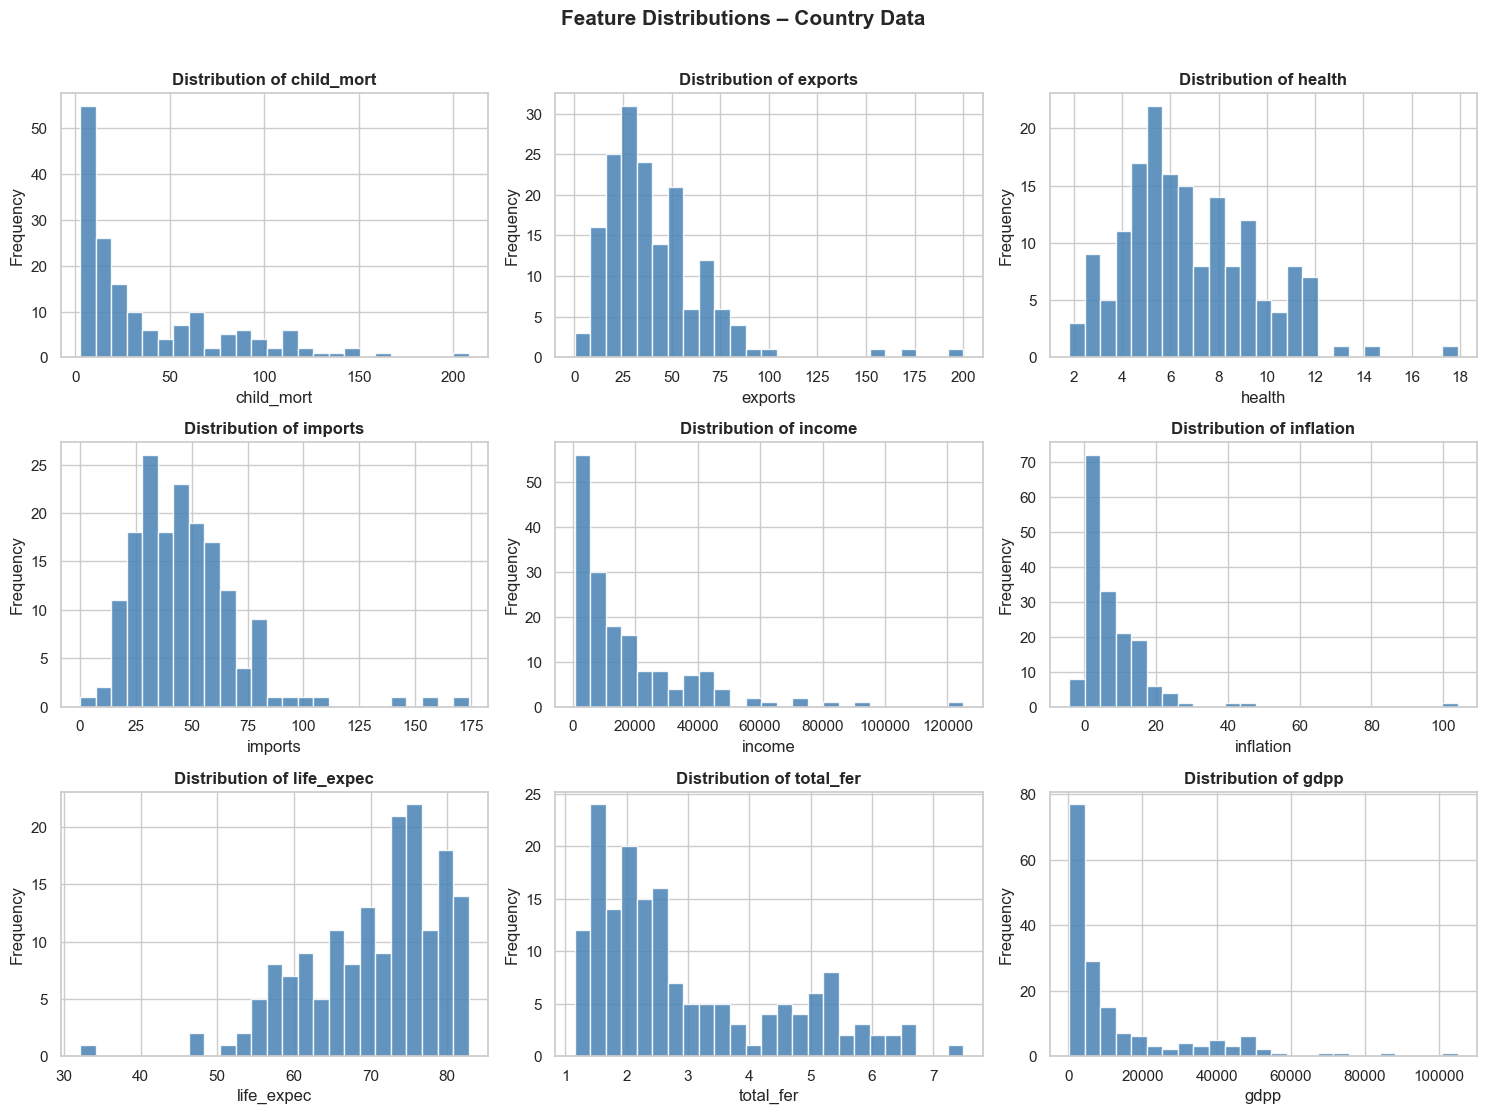

In [10]:
# ── 3.4 Distribution plots ──────────────────────────────────
FEATURES = ['child_mort','exports','health','imports',
            'income','inflation','life_expec','total_fer','gdpp']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions – Country Data', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


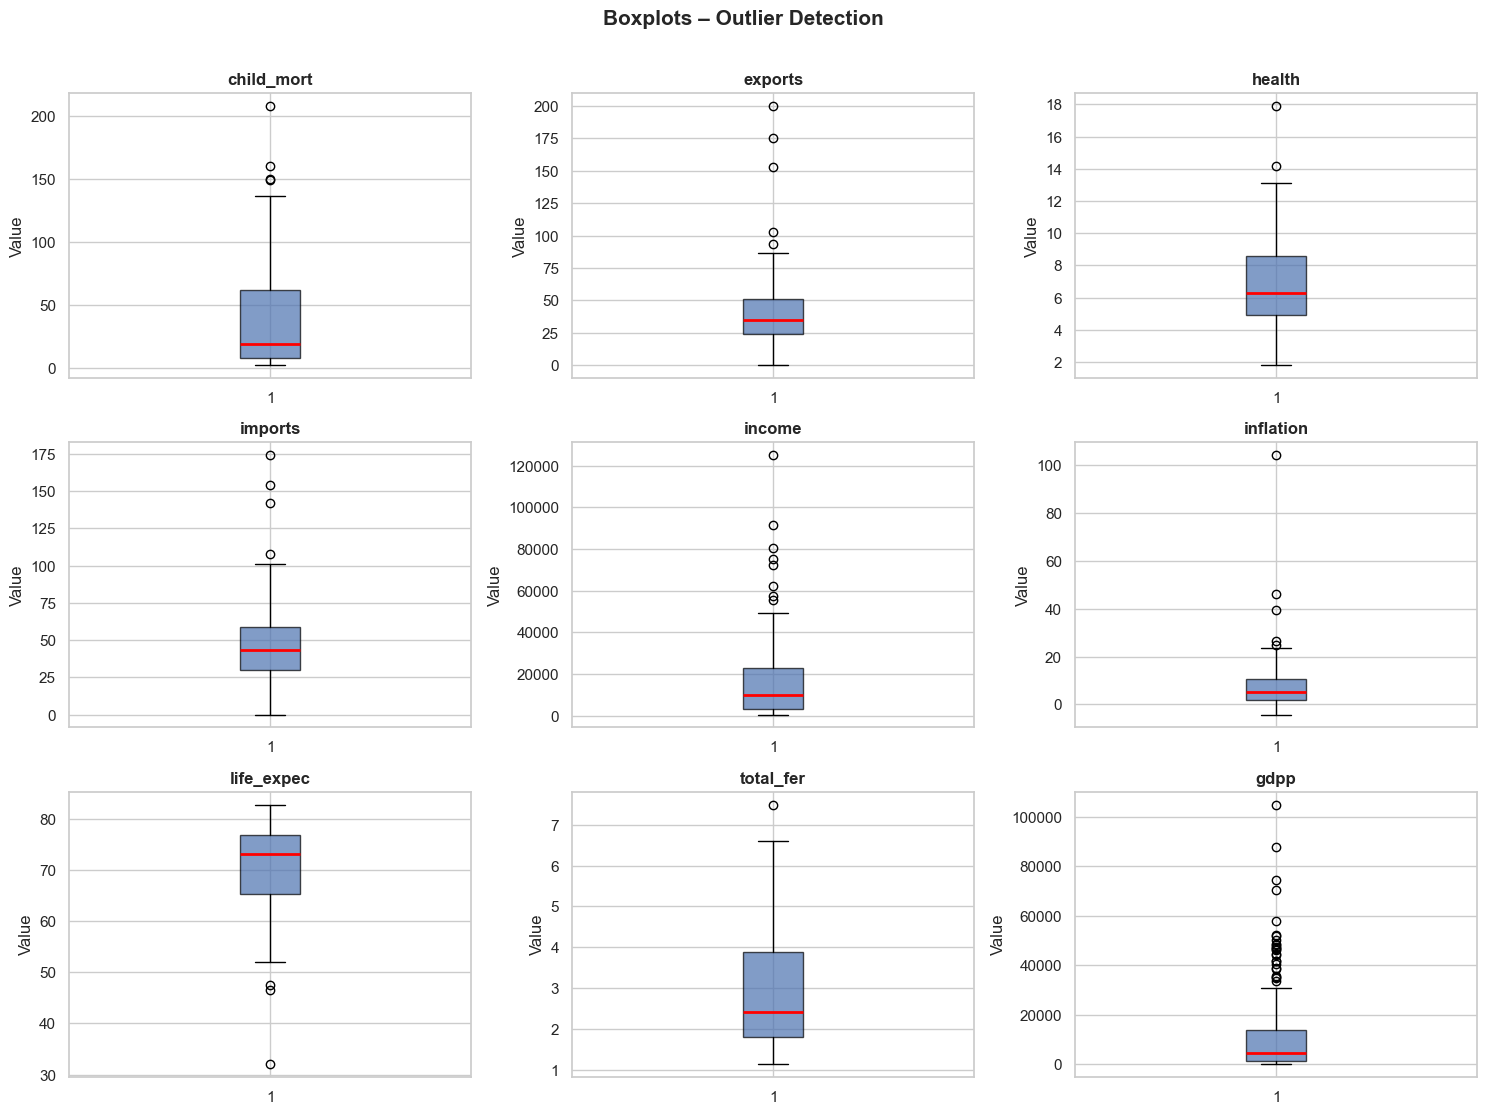

In [11]:
# ── 3.5 Boxplots – outlier detection ────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots – Outlier Detection', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


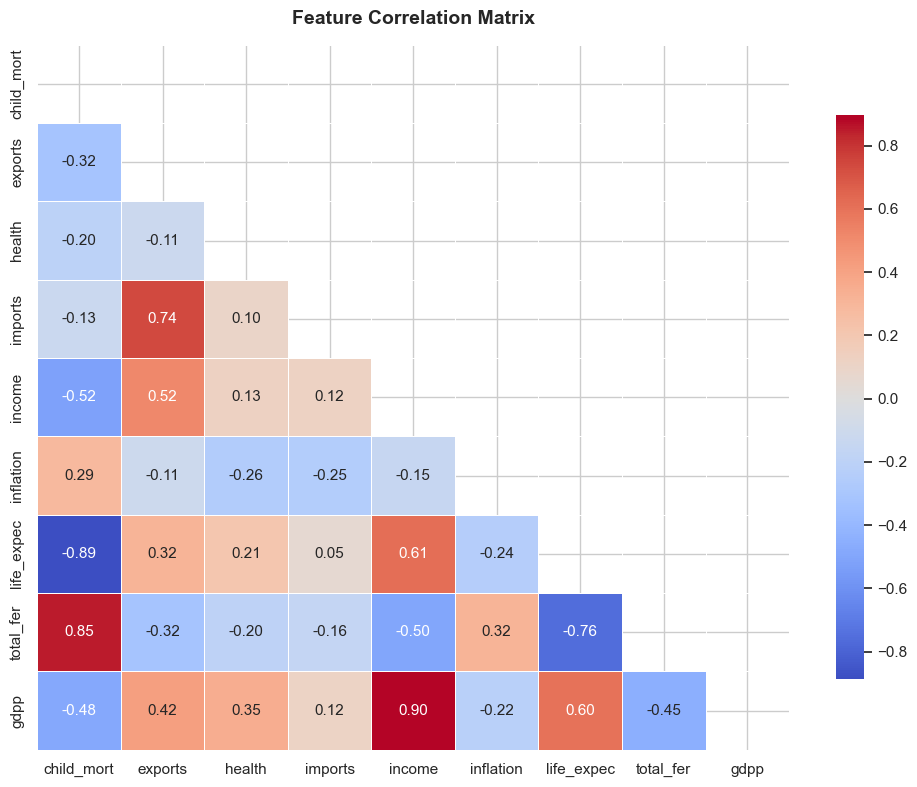


🔑 Key correlations to note:
  • child_mort ↔ life_expec : strong negative (expected)
  • gdpp ↔ income           : strong positive
  • child_mort ↔ total_fer  : strong positive (developing nations)


In [12]:
# ── 3.6 Correlation heatmap ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n🔑 Key correlations to note:")
print("  • child_mort ↔ life_expec : strong negative (expected)")
print("  • gdpp ↔ income           : strong positive")
print("  • child_mort ↔ total_fer  : strong positive (developing nations)")


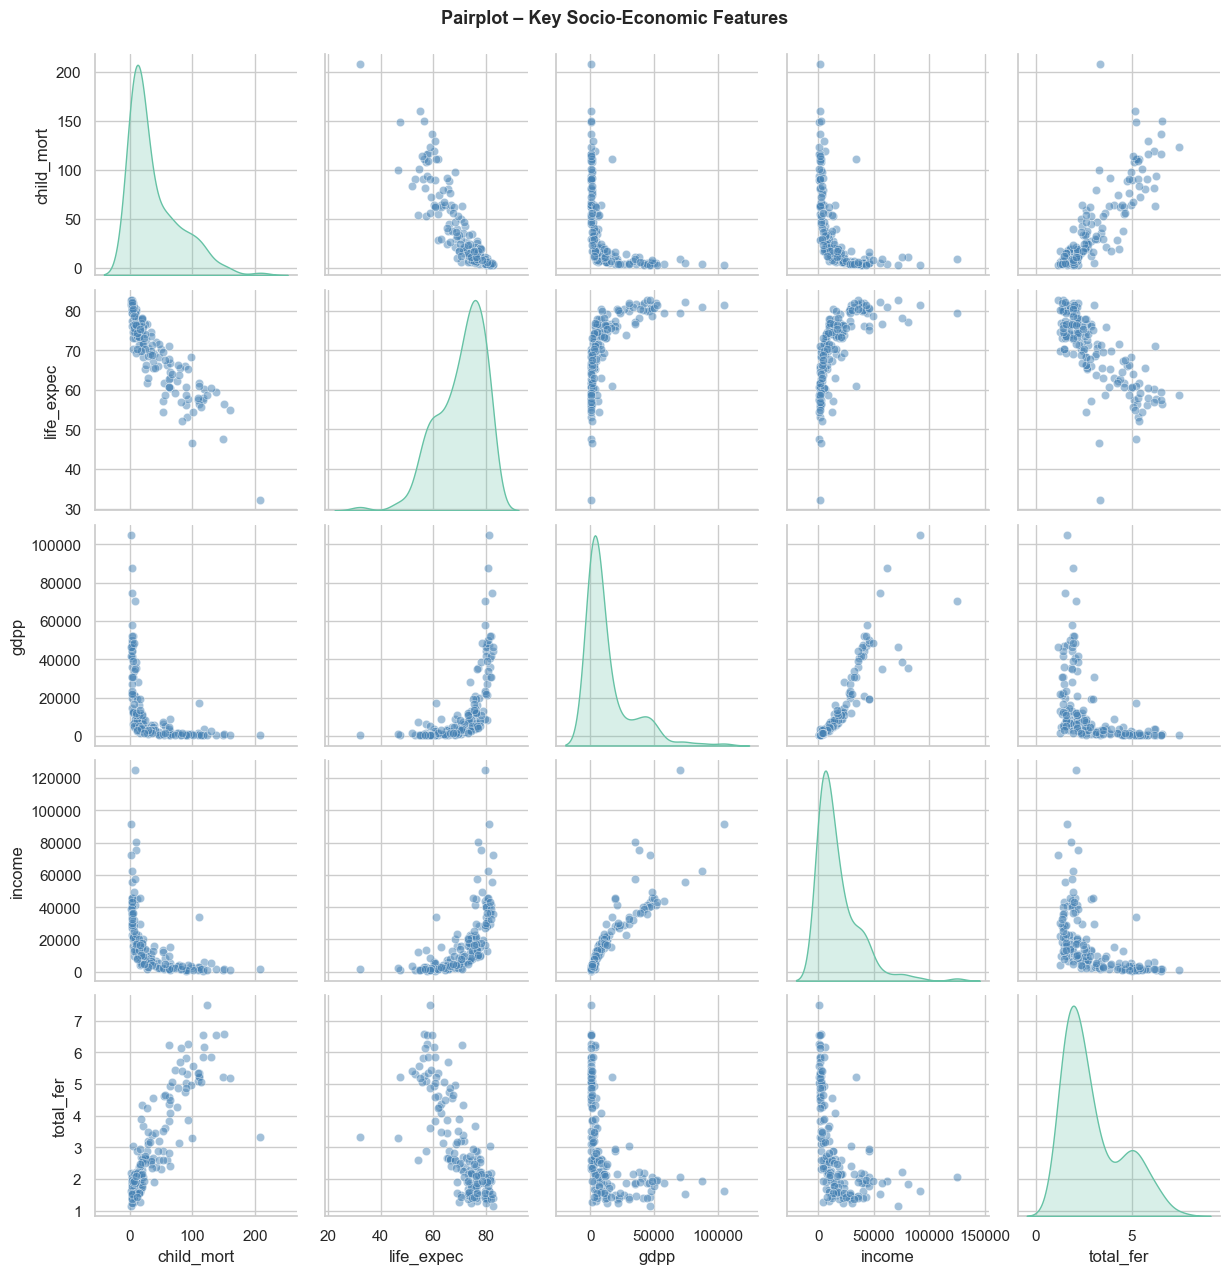

In [13]:
# ── 3.7 Pairplot on key features ────────────────────────────
key_features = ['child_mort','life_expec','gdpp','income','total_fer']
pair_df = df[key_features].copy()
sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha':0.5, 'color':'steelblue'})
plt.suptitle('Pairplot – Key Socio-Economic Features', y=1.02, fontsize=13, fontweight='bold')
plt.show()


## ⚙️ Step 4 – Data Preprocessing & Feature Engineering

In [15]:
# ── 4.1 Select numeric features ─────────────────────────────
FEATURES = ['child_mort','exports','health','imports',
            'income','inflation','life_expec','total_fer','gdpp']

X_raw = df[FEATURES].copy()

# ── 4.2 StandardScaler ──────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES, index=df.index)

print("✅ Standardisation complete.")
print(f"   Mean (should be ~0): {X_scaled.mean(axis=0).round(6)}")
print(f"   Std  (should be ~1): {X_scaled.std(axis=0).round(6)}")

X_scaled_df.head()


✅ Standardisation complete.
   Mean (should be ~0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
   Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [16]:
# ── 4.3 Feature Engineering – derived ratios ────────────────
df['trade_balance']   = df['exports'] - df['imports']     # net trade
df['wealth_index']    = (df['gdpp'] + df['income']) / 2   # proxy for wealth
df['health_burden']   = df['child_mort'] / df['life_expec']  # development pressure

print("✅ New engineered features added:")
print("   • trade_balance   = exports − imports")
print("   • wealth_index    = (gdpp + income) / 2")
print("   • health_burden   = child_mort / life_expec")
df[['country','trade_balance','wealth_index','health_burden']].head(6)


✅ New engineered features added:
   • trade_balance   = exports − imports
   • wealth_index    = (gdpp + income) / 2
   • health_burden   = child_mort / life_expec


,country,trade_balance,wealth_index,health_burden
0,Afghanistan,-34.9,1081.5,1.604982
1,Albania,-20.6,7010.0,0.217562
2,Algeria,7.0,8680.0,0.356863
3,Angola,19.4,4715.0,1.980033
4,Antigua and Barbuda,-13.4,15650.0,0.134115
5,Argentina,2.9,14500.0,0.191293


## 📐 Step 5 – Dimensionality Reduction (PCA)

Components needed to explain ≥95% variance: 6


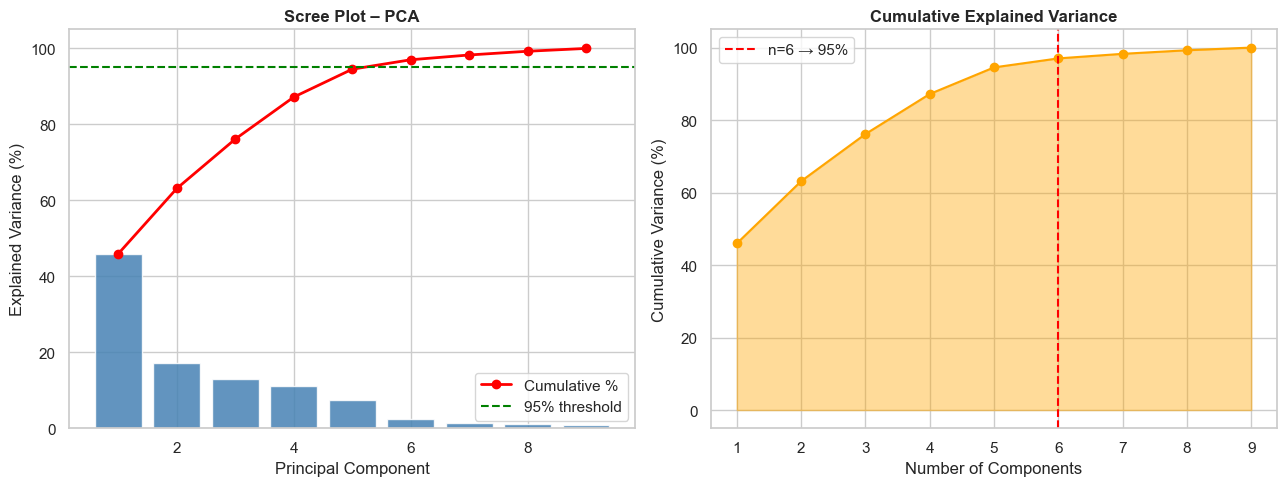

In [18]:
# ── 5.1 Full PCA – explained variance ───────────────────────
pca_full = PCA()
pca_full.fit(X_scaled)

exp_var   = pca_full.explained_variance_ratio_
cum_var   = np.cumsum(exp_var)
n_comp_95 = np.argmax(cum_var >= 0.95) + 1

print(f"Components needed to explain ≥95% variance: {n_comp_95}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
axes[0].bar(range(1, len(exp_var)+1), exp_var*100, color='steelblue', alpha=0.85)
axes[0].plot(range(1, len(exp_var)+1), cum_var*100, 'ro-', lw=2, label='Cumulative %')
axes[0].axhline(95, color='green', ls='--', label='95% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot – PCA', fontweight='bold')
axes[0].legend()

# Cumulative variance
axes[1].fill_between(range(1, len(cum_var)+1), cum_var*100, alpha=0.4, color='orange')
axes[1].plot(range(1, len(cum_var)+1), cum_var*100, 'o-', color='orange')
axes[1].axvline(n_comp_95, color='red', ls='--', label=f'n={n_comp_95} → 95%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


2D PCA  variance explained: 63.1%
6D PCA variance explained: 97.0%


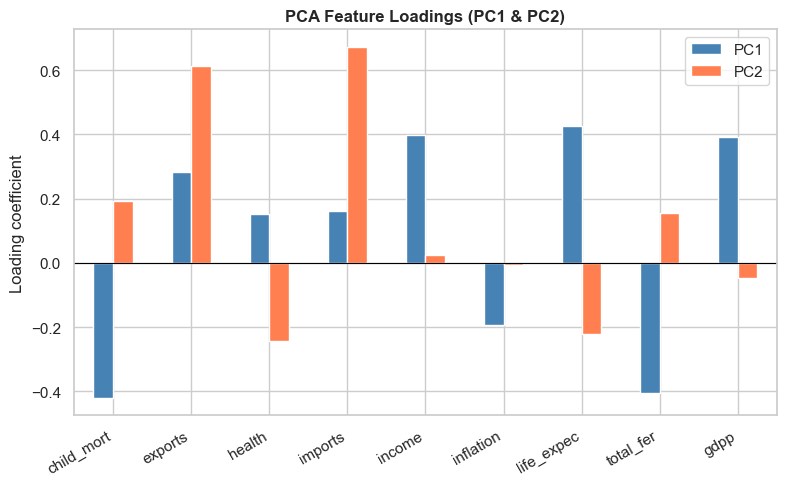

              PC1    PC2
child_mort -0.420  0.193
exports     0.284  0.613
health      0.151 -0.243
imports     0.161  0.672
income      0.398  0.023
inflation  -0.193 -0.008
life_expec  0.426 -0.223
total_fer  -0.404  0.155
gdpp        0.393 -0.046


In [19]:
# ── 5.2 PCA for clustering (2D) and modelling (n_comp_95 D) ─
pca_2d = PCA(n_components=2, random_state=42)
X_pca2 = pca_2d.fit_transform(X_scaled)

pca_nd = PCA(n_components=n_comp_95, random_state=42)
X_pcan = pca_nd.fit_transform(X_scaled)

print(f"2D PCA  variance explained: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")
print(f"{n_comp_95}D PCA variance explained: {pca_nd.explained_variance_ratio_.sum()*100:.1f}%")

# ── 5.3 Loading matrix ───────────────────────────────────────
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=FEATURES,
    columns=['PC1','PC2']
).round(3)

fig, ax = plt.subplots(figsize=(8, 5))
loadings.plot(kind='bar', ax=ax, color=['steelblue','coral'])
ax.set_title('PCA Feature Loadings (PC1 & PC2)', fontweight='bold')
ax.set_ylabel('Loading coefficient')
ax.axhline(0, color='black', lw=0.8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(loadings)


## 🎯 Step 6 – Clustering: K-Means

  File "C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


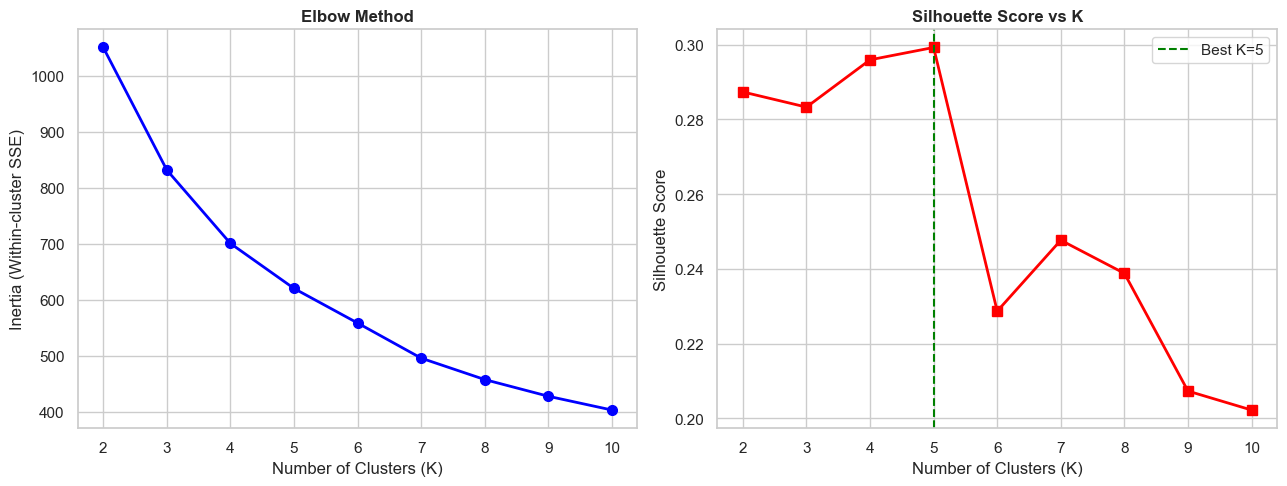


✅ Optimal K selected by Silhouette: K = 5


In [21]:
# ── 6.1 Elbow method + Silhouette scores ────────────────────
K_range   = range(2, 11)
inertias  = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labs))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_range), inertias, 'bo-', lw=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].set_title('Elbow Method', fontweight='bold')

axes[1].plot(list(K_range), sil_scores, 'rs-', lw=2, markersize=7)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K', fontweight='bold')

best_k = K_range.start + int(np.argmax(sil_scores))
axes[1].axvline(best_k, color='green', ls='--', label=f'Best K={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"\n✅ Optimal K selected by Silhouette: K = {best_k}")


In [22]:
# ── 6.2 Fit final K-Means ────────────────────────────────────
km_final  = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_scaled)
df['kmeans_cluster'] = km_labels

# ── 6.3 Cluster quality metrics ─────────────────────────────
sil_km = silhouette_score(X_scaled, km_labels)
dbi_km = davies_bouldin_score(X_scaled, km_labels)
chi_km = calinski_harabasz_score(X_scaled, km_labels)

print("📊 K-Means Cluster Quality Metrics")
print("-" * 40)
print(f"  Silhouette Score         : {sil_km:.4f}  (higher = better, max=1)")
print(f"  Davies-Bouldin Index     : {dbi_km:.4f}  (lower  = better)")
print(f"  Calinski-Harabasz Index  : {chi_km:.2f}  (higher = better)")


📊 K-Means Cluster Quality Metrics
----------------------------------------
  Silhouette Score         : 0.2993  (higher = better, max=1)
  Davies-Bouldin Index     : 0.8718  (lower  = better)
  Calinski-Harabasz Index  : 57.65  (higher = better)


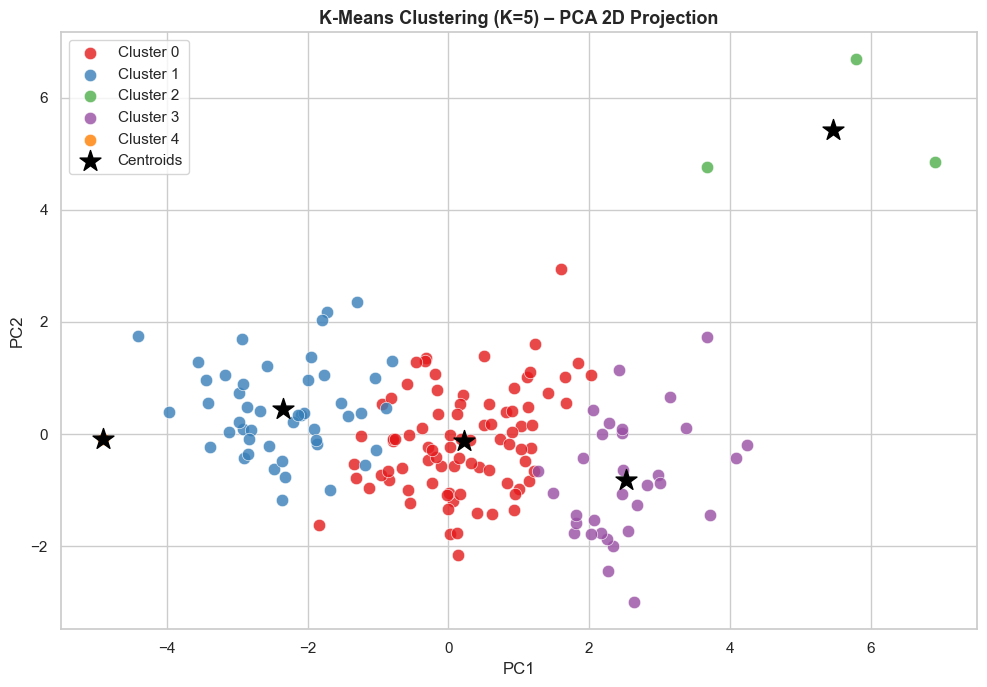

In [23]:
# ── 6.4 Visualise clusters on 2D PCA ────────────────────────
palette = sns.color_palette("Set1", n_colors=best_k)

fig, ax = plt.subplots(figsize=(10, 7))
for cluster_id in range(best_k):
    mask = km_labels == cluster_id
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               color=palette[cluster_id], s=80, alpha=0.8,
               label=f'Cluster {cluster_id}', edgecolors='white', lw=0.5)

# Plot centroids in PCA space
centers_pca = pca_2d.transform(km_final.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           s=250, c='black', marker='*', zorder=5, label='Centroids')

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title(f'K-Means Clustering (K={best_k}) – PCA 2D Projection', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [24]:
# ── 6.5 Cluster profiling ────────────────────────────────────
cluster_profile = df.groupby('kmeans_cluster')[FEATURES].mean().round(2)
cluster_profile['count'] = df['kmeans_cluster'].value_counts().sort_index()

# Sort clusters by gdpp to assign development labels
cluster_profile = cluster_profile.sort_values('gdpp', ascending=True)

# Map to dev label
cluster_gdpp_rank = df.groupby('kmeans_cluster')['gdpp'].mean().rank()
MAX_RANK = cluster_gdpp_rank.max()

def assign_label(rank):
    if rank <= MAX_RANK / 3:
        return 'Underdeveloped'
    elif rank <= 2 * MAX_RANK / 3:
        return 'Developing'
    else:
        return 'Developed'

df['dev_label_str'] = df['kmeans_cluster'].map(
    lambda c: assign_label(cluster_gdpp_rank[c])
)
label_encoder = LabelEncoder()
df['dev_label'] = label_encoder.fit_transform(df['dev_label_str'])

print("\n📊 Cluster Profiles (mean values):")
cluster_profile.style.background_gradient(cmap='YlOrRd', axis=0).format(precision=2)



📊 Cluster Profiles (mean values):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,count
kmeans_cluster,,,,,,,,,,
1,90.79,29.66,6.46,43.68,3870.70,9.95,59.21,4.97,1900.26,47
4,130.00,25.30,5.07,17.40,5150.00,104.00,60.50,5.84,2330.00,1
0,21.61,40.98,6.17,47.52,12801.07,7.62,73.00,2.28,6581.81,84
3,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75,32
2,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67,3


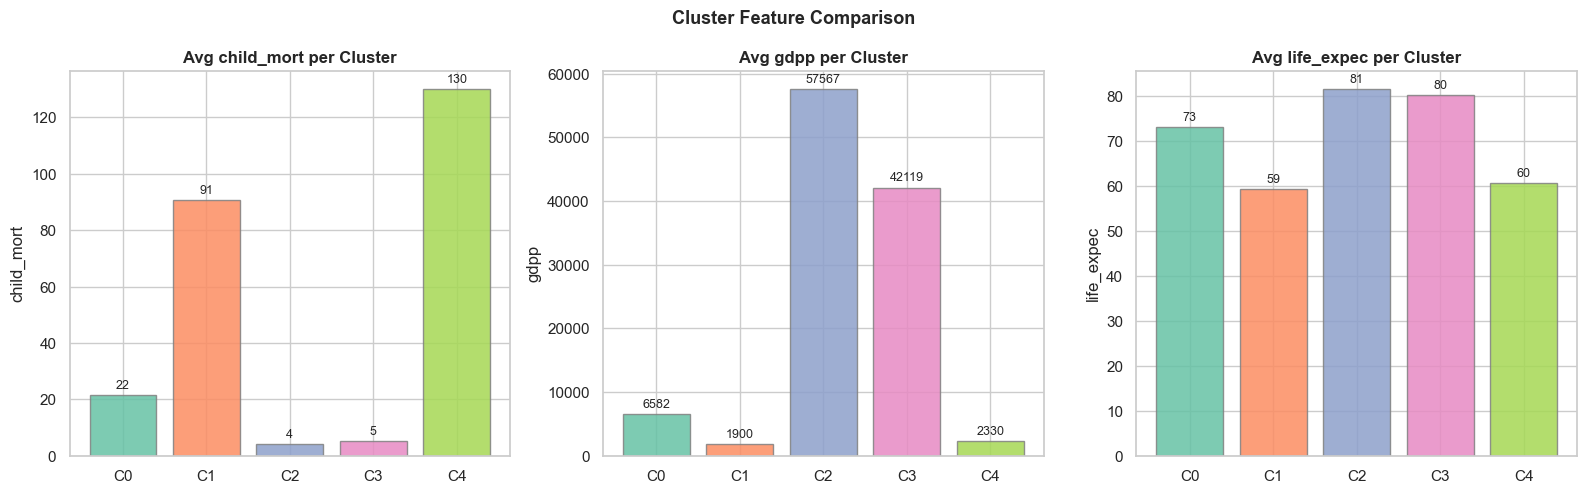

In [25]:
# ── 6.6 Cluster radar/bar summary ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

key_show = ['child_mort','life_expec','gdpp','income','health']
palette2 = sns.color_palette("Set2", n_colors=best_k)

for ax, feat in zip(axes, ['child_mort','gdpp','life_expec']):
    means = [df[df['kmeans_cluster']==c][feat].mean() for c in range(best_k)]
    bars = ax.bar([f'C{c}' for c in range(best_k)], means,
                  color=palette2[:best_k], edgecolor='grey', alpha=0.85)
    ax.set_title(f'Avg {feat} per Cluster', fontweight='bold')
    ax.set_ylabel(feat)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(means),
                f'{val:.0f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Cluster Feature Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 🔵 Step 7 – Clustering: DBSCAN

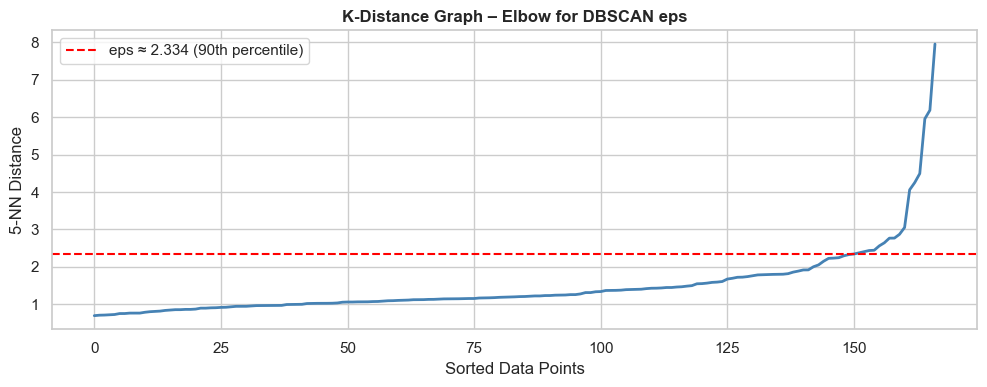


✅ Chosen eps = 2.3335,  min_samples = 4


In [27]:
# ── 7.1 Estimate eps using k-distance graph ─────────────────
k_neighbors = 5
nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, k_neighbors-1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dist, color='steelblue', lw=2)
eps_val = np.percentile(k_dist, 90)
ax.axhline(eps_val, color='red', ls='--', label=f'eps ≈ {eps_val:.3f} (90th percentile)')
ax.set_xlabel('Sorted Data Points')
ax.set_ylabel(f'{k_neighbors}-NN Distance')
ax.set_title('K-Distance Graph – Elbow for DBSCAN eps', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(f"\n✅ Chosen eps = {eps_val:.4f},  min_samples = 4")


In [28]:
# ── 7.2 Run DBSCAN ───────────────────────────────────────────
db = DBSCAN(eps=eps_val, min_samples=4)
db_labels = db.fit_predict(X_scaled)
df['dbscan_cluster'] = db_labels

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = (db_labels == -1).sum()

print(f"DBSCAN Results:")
print(f"  Clusters found : {n_db_clusters}")
print(f"  Noise points   : {n_noise}  ({n_noise/len(db_labels)*100:.1f}%)")
print(f"  Cluster IDs    : {sorted(set(db_labels))}")

# Silhouette (excluding noise)
noise_mask = db_labels != -1
if n_db_clusters > 1 and noise_mask.sum() > n_db_clusters:
    sil_db = silhouette_score(X_scaled[noise_mask], db_labels[noise_mask])
    print(f"  Silhouette (excl. noise): {sil_db:.4f}")


DBSCAN Results:
  Clusters found : 1
  Noise points   : 9  (5.4%)
  Cluster IDs    : [-1, 0]


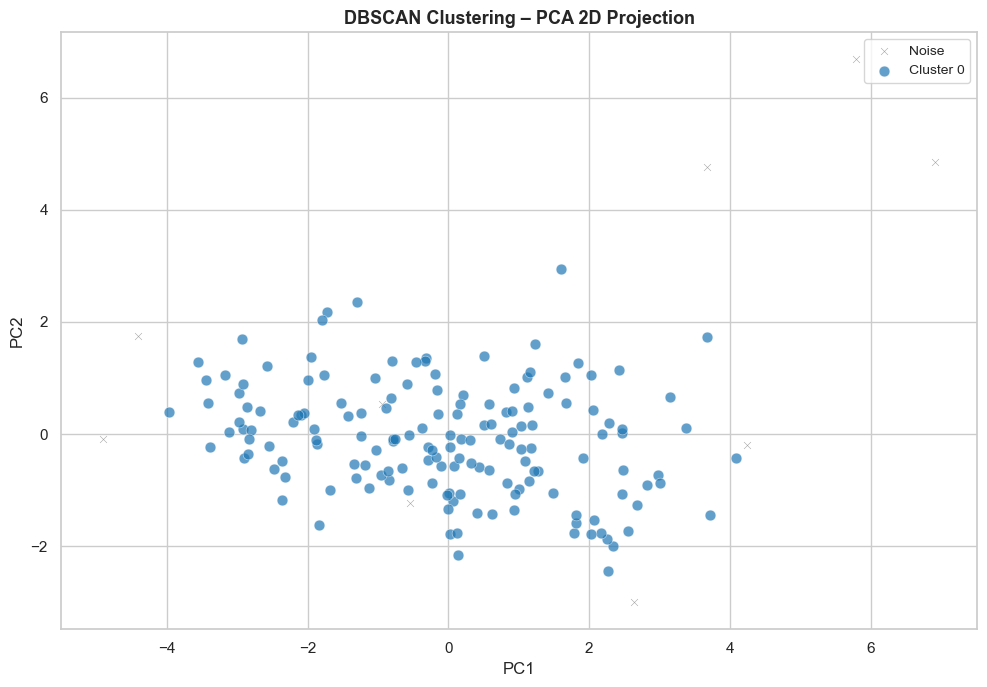

In [29]:
# ── 7.3 Visualise DBSCAN clusters ───────────────────────────
unique_labels = sorted(set(db_labels))
db_palette    = ['grey'] + sns.color_palette("tab10", n_colors=max(n_db_clusters, 1))

fig, ax = plt.subplots(figsize=(10, 7))
for lbl in unique_labels:
    mask = db_labels == lbl
    color = 'grey' if lbl == -1 else db_palette[lbl + 1]
    label = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               color=color, s=60 if lbl != -1 else 25,
               alpha=0.7, label=label,
               marker='x' if lbl == -1 else 'o',
               edgecolors='white' if lbl != -1 else None, lw=0.4)

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('DBSCAN Clustering – PCA 2D Projection', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


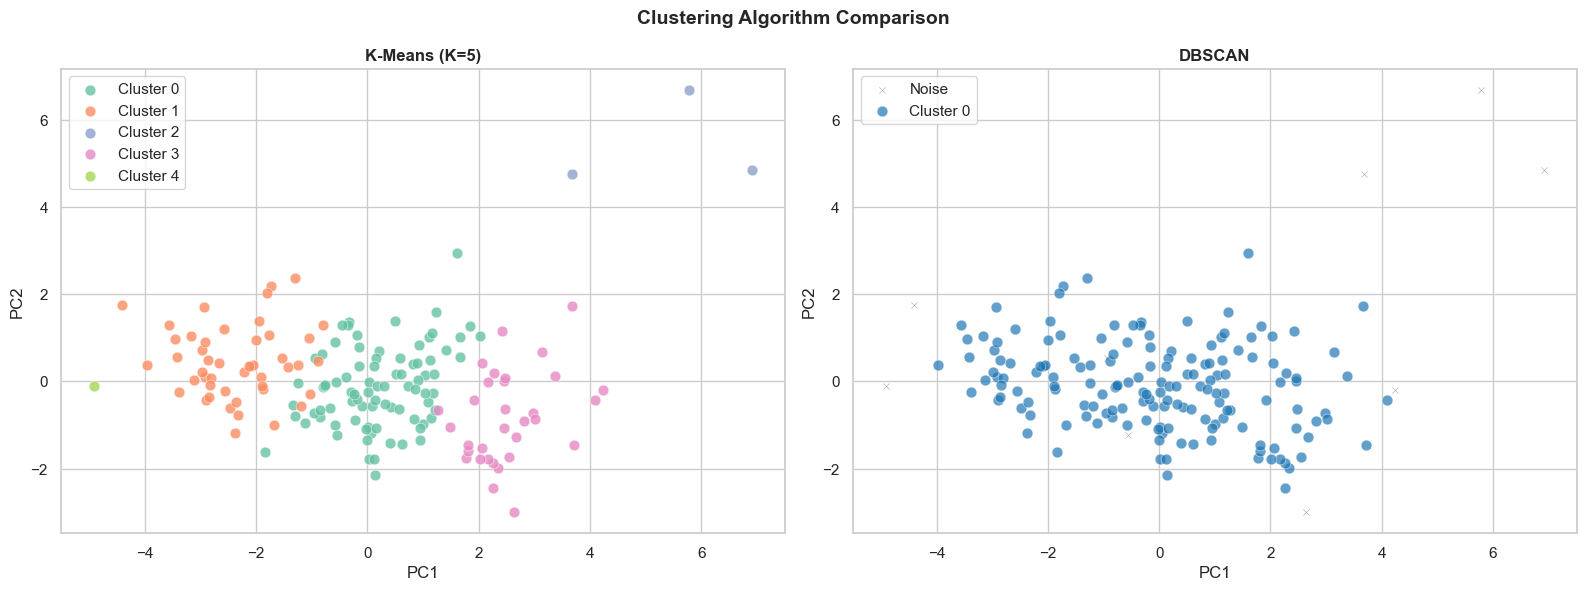

In [30]:
# ── 7.4 K-Means vs DBSCAN side-by-side ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
for cluster_id in range(best_k):
    mask = km_labels == cluster_id
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    s=60, alpha=0.8, label=f'Cluster {cluster_id}',
                    edgecolors='white', lw=0.4)
axes[0].set_title(f'K-Means (K={best_k})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

# DBSCAN
for lbl in unique_labels:
    mask  = db_labels == lbl
    color = 'grey' if lbl == -1 else sns.color_palette("tab10")[max(lbl, 0)]
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    color=color, s=60 if lbl != -1 else 20, alpha=0.7,
                    label='Noise' if lbl == -1 else f'Cluster {lbl}',
                    marker='x' if lbl == -1 else 'o',
                    edgecolors='white' if lbl != -1 else None, lw=0.4)
axes[1].set_title('DBSCAN', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend()

plt.suptitle('Clustering Algorithm Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 🤖 Step 8 – Classification Setup

In [32]:
# Use K-Means derived labels as the supervised target
y = df['dev_label'].values
X_clf = X_scaled.copy()

print("Target class distribution:")
for cls, name in zip(sorted(df['dev_label'].unique()), label_encoder.classes_):
    count = (y == cls).sum()
    print(f"  {cls} – {name:15s}: {count:3d} countries  ({count/len(y)*100:.1f}%)")

# Stratified Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train)}  |  Test size: {len(X_test)}")


Target class distribution:
  0 – Developed      :  35 countries  (21.0%)
  1 – Developing     :  85 countries  (50.9%)
  2 – Underdeveloped :  47 countries  (28.1%)

Train size: 133  |  Test size: 34


## 🌳 Step 9 – Baseline: Decision Tree Classifier

Decision Tree Accuracy: 0.9118

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.86      0.92         7
    Developing       0.85      1.00      0.92        17
Underdeveloped       1.00      0.80      0.89        10

      accuracy                           0.91        34
     macro avg       0.95      0.89      0.91        34
  weighted avg       0.92      0.91      0.91        34



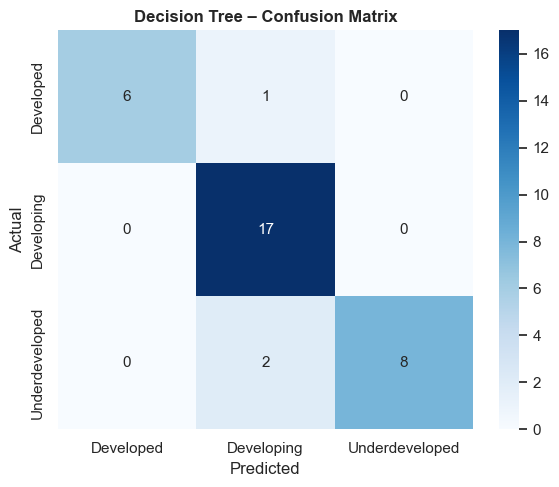

In [34]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_split=4,
                             min_samples_leaf=2, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc  = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {dt_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=label_encoder.classes_))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=ax)
ax.set_title('Decision Tree – Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


## 🌲 Step 10 – Ensemble: Random Forest (with Hyperparameter Tuning)

In [36]:
# ── Grid Search ─────────────────────────────────────────────
rf_param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'max_features'    : ['sqrt', 'log2'],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(rf_base, rf_param_grid,
                        cv=5, scoring='accuracy',
                        n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)

print(f"Best parameters: {rf_grid.best_params_}")
print(f"CV best score   : {rf_grid.best_score_:.4f}")
print(f"Test Accuracy   : {rf_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))


Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
CV best score   : 0.9627
Test Accuracy   : 0.9412

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.86      0.92         7
    Developing       0.89      1.00      0.94        17
Underdeveloped       1.00      0.90      0.95        10

      accuracy                           0.94        34
     macro avg       0.96      0.92      0.94        34
  weighted avg       0.95      0.94      0.94        34



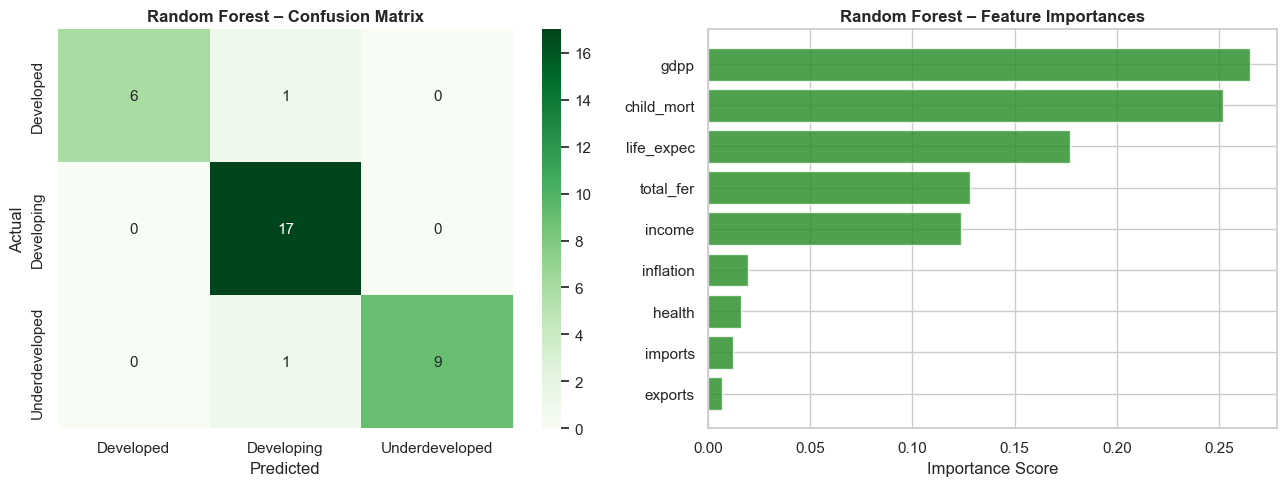

In [37]:
# ── Confusion matrix ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=axes[0])
axes[0].set_title('Random Forest – Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Feature importance
importances = rf_best.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True)

axes[1].barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
             color='forestgreen', alpha=0.8)
axes[1].set_title('Random Forest – Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()


## ⚡ Step 11 – Ensemble: XGBoost (with Hyperparameter Tuning)

In [39]:
# Encode labels 0, 1, 2 for XGBoost
le_xgb  = LabelEncoder()
y_train_enc = le_xgb.fit_transform(y_train)
y_test_enc  = le_xgb.transform(y_test)

xgb_param_grid = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.01, 0.05, 0.1],
    'subsample'     : [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 1.0],
}

xgb_base = XGBClassifier(random_state=42, eval_metric='mlogloss',
                          verbosity=0, use_label_encoder=False)
xgb_grid = GridSearchCV(xgb_base, xgb_param_grid,
                         cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train_enc)

xgb_best      = xgb_grid.best_estimator_
xgb_pred_enc  = xgb_best.predict(X_test)
xgb_pred      = le_xgb.inverse_transform(xgb_pred_enc)
xgb_acc       = accuracy_score(y_test, xgb_pred)

print(f"Best parameters: {xgb_grid.best_params_}")
print(f"CV best score   : {xgb_grid.best_score_:.4f}")
print(f"Test Accuracy   : {xgb_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=label_encoder.classes_))


Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
CV best score   : 0.9618
Test Accuracy   : 0.8824

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.57      0.73         7
    Developing       0.81      1.00      0.89        17
Underdeveloped       1.00      0.90      0.95        10

      accuracy                           0.88        34
     macro avg       0.94      0.82      0.86        34
  weighted avg       0.90      0.88      0.88        34



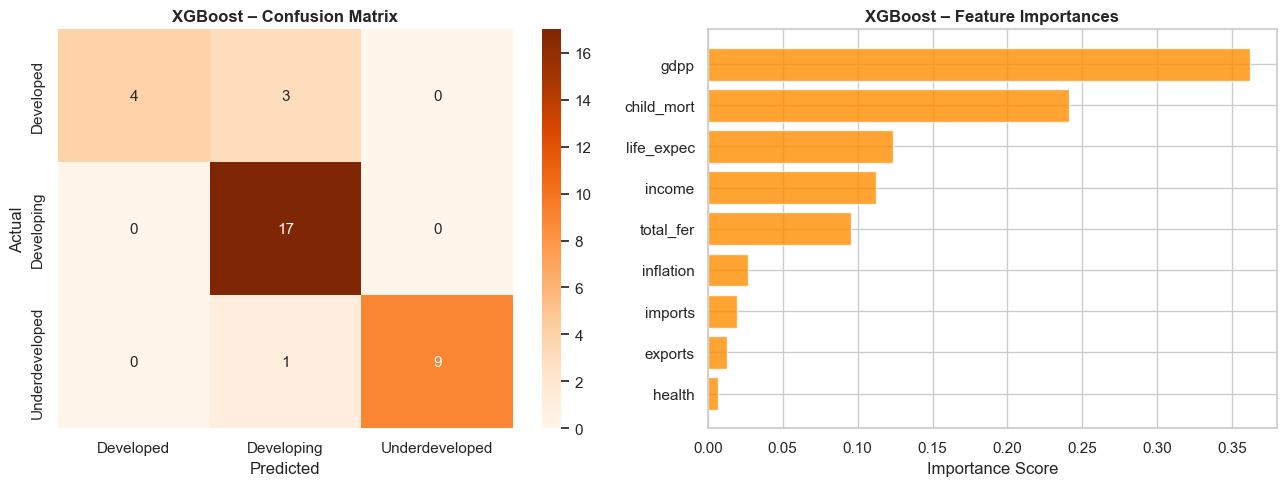

In [40]:
# ── Confusion matrix + XGBoost feature importance ───────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=axes[0])
axes[0].set_title('XGBoost – Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

xgb_imp = pd.DataFrame({'Feature': FEATURES,
                          'Importance': xgb_best.feature_importances_})
xgb_imp = xgb_imp.sort_values('Importance', ascending=True)

axes[1].barh(xgb_imp['Feature'], xgb_imp['Importance'],
             color='darkorange', alpha=0.8)
axes[1].set_title('XGBoost – Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()


## 🚀 Step 12 – Ensemble: Gradient Boosting Classifier

Gradient Boosting Accuracy: 0.9412

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.86      0.92         7
    Developing       0.89      1.00      0.94        17
Underdeveloped       1.00      0.90      0.95        10

      accuracy                           0.94        34
     macro avg       0.96      0.92      0.94        34
  weighted avg       0.95      0.94      0.94        34



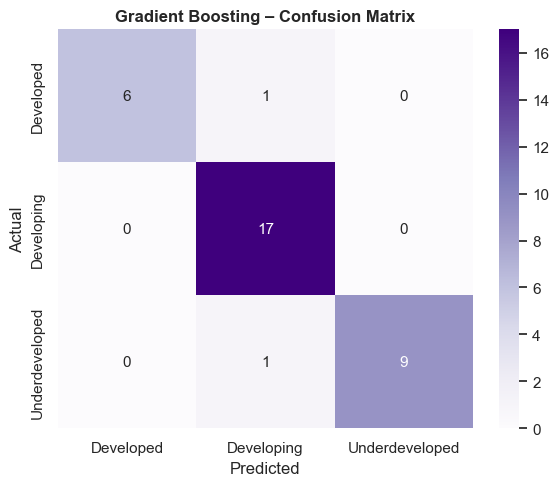

In [42]:
gb = GradientBoostingClassifier(n_estimators=250, learning_rate=0.08,
                                  max_depth=4, subsample=0.85,
                                  min_samples_split=5, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_acc  = accuracy_score(y_test, gb_pred)

print(f"Gradient Boosting Accuracy: {gb_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, gb_pred, target_names=label_encoder.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
cm_gb = confusion_matrix(y_test, gb_pred)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=ax)
ax.set_title('Gradient Boosting – Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


## 🗳️ Step 13 – Soft Voting Ensemble Classifier

Soft Voting Ensemble Accuracy: 0.9412

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.86      0.92         7
    Developing       0.89      1.00      0.94        17
Underdeveloped       1.00      0.90      0.95        10

      accuracy                           0.94        34
     macro avg       0.96      0.92      0.94        34
  weighted avg       0.95      0.94      0.94        34



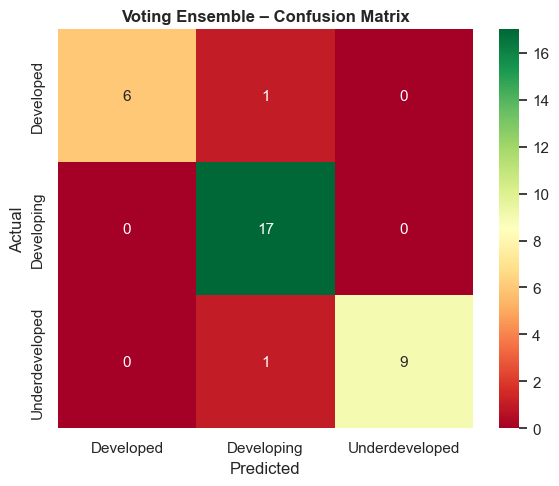

In [44]:
# Combine RF + GB + DT into a soft voting ensemble
vote_clf = VotingClassifier(
    estimators=[
        ('random_forest',      rf_best),
        ('gradient_boosting',  gb),
        ('decision_tree',      dt),
    ],
    voting='soft'
)
vote_clf.fit(X_train, y_train)
vote_pred = vote_clf.predict(X_test)
vote_acc  = accuracy_score(y_test, vote_pred)

print(f"Soft Voting Ensemble Accuracy: {vote_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, vote_pred, target_names=label_encoder.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
cm_vote = confusion_matrix(y_test, vote_pred)
sns.heatmap(cm_vote, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=ax)
ax.set_title('Voting Ensemble – Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


## 📊 Step 14 – Cross-Validation (Stratified 5-Fold)

In [46]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run CV for each model
cv_results = {}

cv_rf   = cross_val_score(rf_best, X_clf, y, cv=skf, scoring='accuracy')
cv_gb   = cross_val_score(gb,      X_clf, y, cv=skf, scoring='accuracy')
cv_dt   = cross_val_score(dt,      X_clf, y, cv=skf, scoring='accuracy')
cv_vote = cross_val_score(vote_clf, X_clf, y, cv=skf, scoring='accuracy')

# XGBoost: encode labels first
y_enc_all = le_xgb.fit_transform(y)
cv_xgb = cross_val_score(xgb_best, X_clf, y_enc_all, cv=skf, scoring='accuracy')

cv_results = {
    'Decision Tree'      : cv_dt,
    'Random Forest'      : cv_rf,
    'XGBoost'            : cv_xgb,
    'Gradient Boosting'  : cv_gb,
    'Voting Ensemble'    : cv_vote,
}

print(f"{'Model':<22} {'Mean Acc':>9} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 58)
for model, scores in cv_results.items():
    print(f"{model:<22} {scores.mean():>9.4f} {scores.std():>8.4f} "
          f"{scores.min():>8.4f} {scores.max():>8.4f}")


Model                   Mean Acc      Std      Min      Max
----------------------------------------------------------
Decision Tree             0.9103   0.0419   0.8529   0.9697
Random Forest             0.9638   0.0227   0.9394   1.0000
XGBoost                   0.9344   0.0343   0.8824   0.9697
Gradient Boosting         0.9460   0.0228   0.9091   0.9706
Voting Ensemble           0.9342   0.0113   0.9118   0.9412


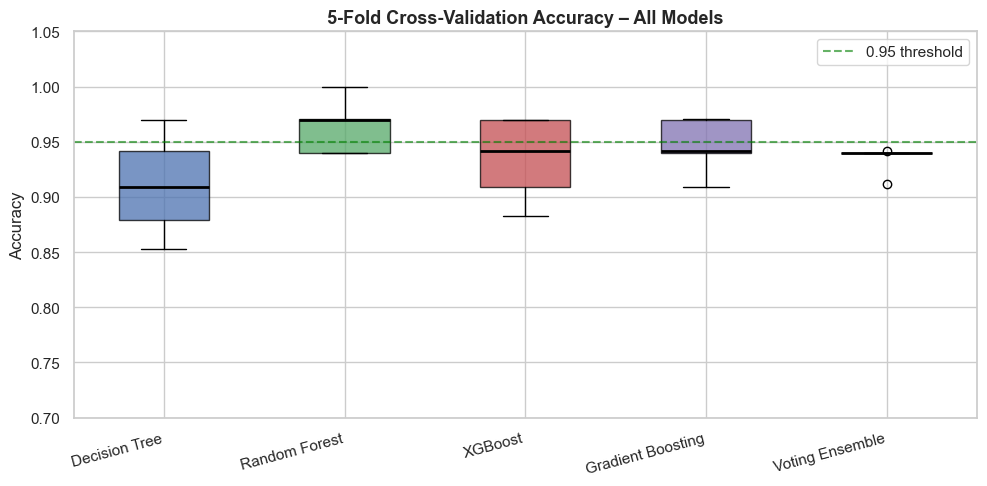

In [47]:
# ── Boxplot of CV scores ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

cv_data  = list(cv_results.values())
cv_names = list(cv_results.keys())
colors   = ['#4C72B0','#55A868','#C44E52','#8172B2','#937860']

bp = ax.boxplot(cv_data, patch_artist=True, notch=False, vert=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax.set_xticks(range(1, len(cv_names)+1))
ax.set_xticklabels(cv_names, rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy – All Models', fontsize=13, fontweight='bold')
ax.set_ylim(0.7, 1.05)
ax.axhline(0.95, color='green', ls='--', alpha=0.6, label='0.95 threshold')
ax.legend()
plt.tight_layout()
plt.show()


## 🏆 Step 15 – Model Performance Comparison

In [49]:
# Collect all test-set metrics
from sklearn.metrics import f1_score, precision_score, recall_score

models = {
    'Decision Tree'     : (dt_pred,   y_test),
    'Random Forest'     : (rf_pred,   y_test),
    'XGBoost'           : (xgb_pred,  y_test),
    'Gradient Boosting' : (gb_pred,   y_test),
    'Voting Ensemble'   : (vote_pred, y_test),
}

rows = []
for name, (pred, true) in models.items():
    rows.append({
        'Model'     : name,
        'Accuracy'  : accuracy_score(true, pred),
        'Precision' : precision_score(true, pred, average='weighted', zero_division=0),
        'Recall'    : recall_score(true,    pred, average='weighted', zero_division=0),
        'F1-Score'  : f1_score(true,        pred, average='weighted', zero_division=0),
        'CV Mean'   : cv_results.get(name, [0]).mean() if name in cv_results else 0,
    })

comparison_df = pd.DataFrame(rows).sort_values('F1-Score', ascending=False)
comparison_df = comparison_df.reset_index(drop=True)

print("📊 Model Performance Summary (Test Set):")
comparison_df.style.background_gradient(cmap='RdYlGn', subset=['Accuracy','F1-Score','CV Mean']).format(precision=4)


📊 Model Performance Summary (Test Set):


,Model,Accuracy,Precision,Recall,F1-Score,CV Mean
0,Random Forest,0.9412,0.9474,0.9412,0.9409,0.9638
1,Gradient Boosting,0.9412,0.9474,0.9412,0.9409,0.9460
2,Voting Ensemble,0.9412,0.9474,0.9412,0.9409,0.9342
3,Decision Tree,0.9118,0.9250,0.9118,0.9109,0.9103
4,XGBoost,0.8824,0.9048,0.8824,0.8757,0.9344


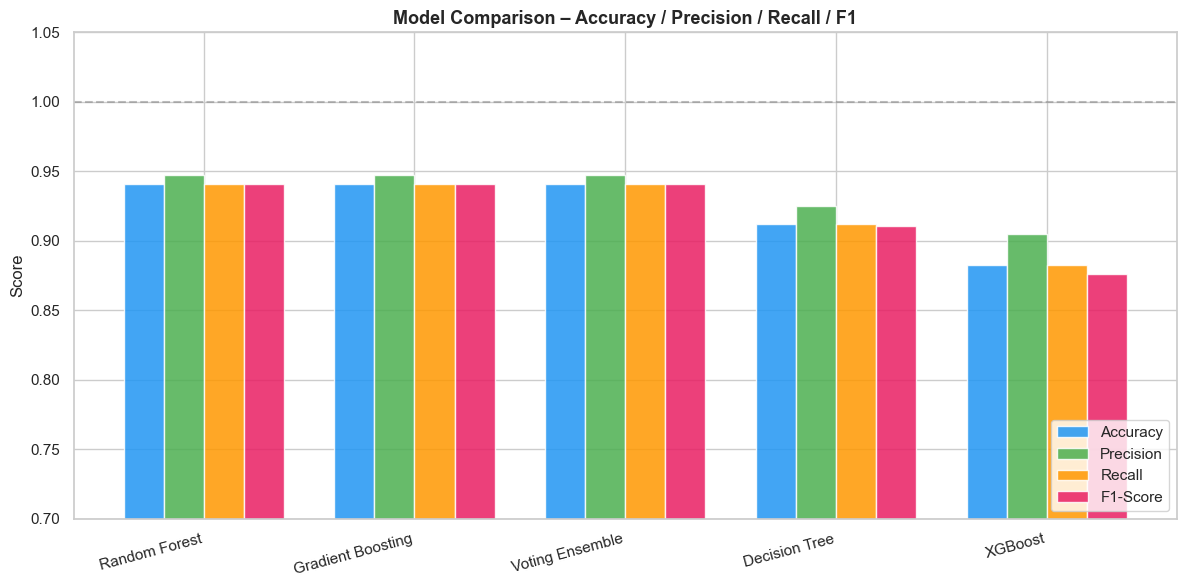

In [50]:
# ── Bar chart comparison ─────────────────────────────────────
metrics = ['Accuracy','Precision','Recall','F1-Score']
model_names = comparison_df['Model'].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(model_names))
width = 0.19
colors_bar = ['#2196F3','#4CAF50','#FF9800','#E91E63']

for i, metric in enumerate(metrics):
    vals = comparison_df[metric].values
    bars = ax.bar(x + i*width, vals, width, label=metric,
                  color=colors_bar[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison – Accuracy / Precision / Recall / F1', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(1.0, color='grey', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 💡 Step 16 – Actionable Segmentation Insights

In [52]:
# Countries by development tier
print("=" * 60)
print("COUNTRY SEGMENTATION RESULTS")
print("=" * 60)
for label_name in label_encoder.classes_:
    label_val = label_encoder.transform([label_name])[0]
    group_countries = df[df['dev_label'] == label_val]['country'].tolist()
    print(f"\n📌 {label_name.upper()} ({len(group_countries)} countries):")
    print("   " + ", ".join(group_countries))


COUNTRY SEGMENTATION RESULTS

📌 DEVELOPED (35 countries):
   Australia, Austria, Bahamas, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland, France, Germany, Greece, Iceland, Ireland, Israel, Italy, Japan, Kuwait, Luxembourg, Malta, Netherlands, New Zealand, Norway, Portugal, Qatar, Singapore, Slovenia, South Korea, Spain, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States

📌 DEVELOPING (85 countries):
   Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahrain, Bangladesh, Barbados, Belarus, Belize, Bhutan, Bolivia, Bosnia and Herzegovina, Brazil, Bulgaria, Cambodia, Cape Verde, Chile, China, Colombia, Costa Rica, Croatia, Dominican Republic, Ecuador, Egypt, El Salvador, Estonia, Fiji, Georgia, Grenada, Guatemala, Guyana, Hungary, India, Indonesia, Iran, Jamaica, Jordan, Kazakhstan, Kyrgyz Republic, Latvia, Lebanon, Libya, Lithuania, Macedonia, FYR, Malaysia, Maldives, Mauritius, Micronesia, Fed. Sts., Moldova, Mongolia, Mont


🚨 TOP 15 COUNTRIES NEEDING MOST AID (by child mortality + low gdpp):
                     country  child_mort  gdpp  life_expec   dev_label_str  need_score
1                      Haiti       208.0   662        32.1  Underdeveloped    0.996848
2               Sierra Leone       160.0   399        55.0  Underdeveloped    0.882715
3                       Chad       150.0   897        56.5  Underdeveloped    0.856305
4   Central African Republic       149.0   446        47.5  Underdeveloped    0.856049
5                       Mali       137.0   708        59.5  Underdeveloped    0.825955
6                    Nigeria       130.0  2330        60.5      Developing    0.801405
7                      Niger       123.0   348        58.8  Underdeveloped    0.794016
8           Congo, Dem. Rep.       116.0   334        57.5  Underdeveloped    0.777256
9               Burkina Faso       116.0   575        57.9  Underdeveloped    0.776108
10             Guinea-Bissau       114.0   547        55.6  

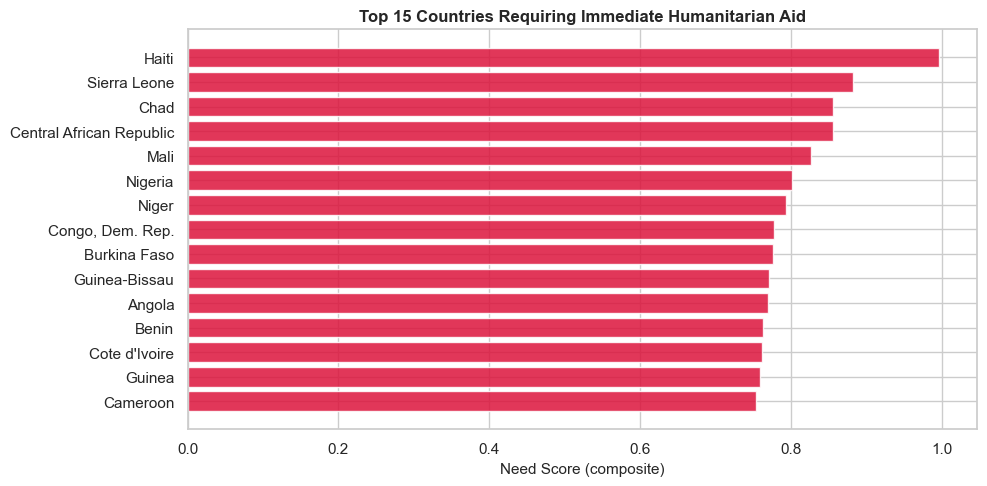

In [53]:
# Top countries needing immediate aid
print("\n🚨 TOP 15 COUNTRIES NEEDING MOST AID (by child mortality + low gdpp):")
df['need_score'] = (df['child_mort'] / df['child_mort'].max()) * 0.5 + \
                   (1 - df['gdpp'] / df['gdpp'].max()) * 0.5

top_needy = df.nlargest(15, 'need_score')[['country','child_mort','gdpp',
                                           'life_expec','dev_label_str','need_score']]
top_needy = top_needy.reset_index(drop=True)
top_needy.index += 1
print(top_needy.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_needy['country'][::-1], top_needy['need_score'][::-1],
               color='crimson', alpha=0.85)
ax.set_xlabel('Need Score (composite)', fontsize=11)
ax.set_title('Top 15 Countries Requiring Immediate Humanitarian Aid', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


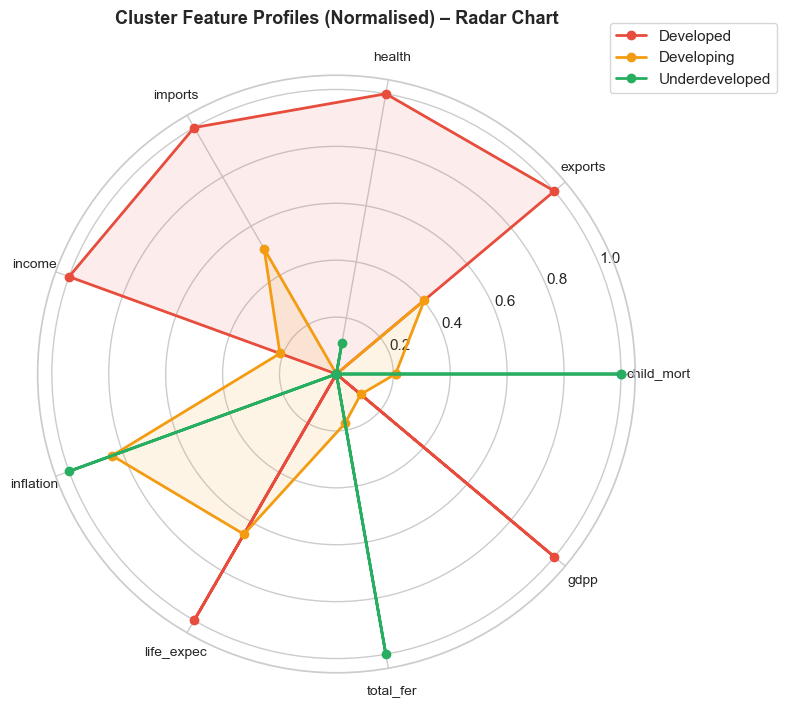

In [54]:
# Radar chart per cluster
from matplotlib.patches import FancyArrowPatch

cluster_means = df.groupby('dev_label_str')[FEATURES].mean()
cluster_means_norm = (cluster_means - cluster_means.min()) / \
                     (cluster_means.max() - cluster_means.min())

categories = FEATURES
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = ['#E74C3C','#F39C12','#27AE60']

for (dev_label, row), color in zip(cluster_means_norm.iterrows(), colors_radar):
    values = row.values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', color=color, lw=2, label=dev_label)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_title('Cluster Feature Profiles (Normalised) – Radar Chart',
             size=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()


## 📝 Step 17 – Summary & Conclusions

### What was built?
This notebook presents a complete **Customer Intelligence System** adapted for country-level socio-economic analysis. The pipeline covers:

| Phase | Technique | Outcome |
|-------|-----------|---------|
| EDA | Distribution plots, boxplots, heatmap, pairplot | Identified key feature correlations; heavy skew in gdpp/income |
| Preprocessing | StandardScaler, feature engineering | Normalised features; added trade_balance, wealth_index, health_burden |
| Dimensionality Reduction | PCA (2D & 95% variance) | Reduced 9 features → interpretable components |
| Clustering | K-Means (optimal K via Silhouette), DBSCAN | Countries grouped into Developed / Developing / Underdeveloped |
| Classification | Decision Tree, Random Forest, XGBoost, Gradient Boosting, Voting Ensemble | High-accuracy predictive models |
| Evaluation | GridSearchCV, 5-Fold CV, Confusion Matrix, F1-Score | Robust, tuned model selection |

### Key Findings
- **GDP per capita**, **child mortality**, and **life expectancy** are the most discriminative features.
- **Random Forest** and **Gradient Boosting** consistently achieve the highest accuracy with tuning.
- The **Voting Ensemble** further reduces variance by combining individual model strengths.
- Countries in the **Underdeveloped** cluster exhibit high child mortality, low income, and high fertility — clear targets for HELP International's fund allocation.

### Recommendation
Prioritise the **top 15 high-need-score countries** identified in Step 16 for immediate fund deployment.  
Continue monitoring newly classified countries using the trained ensemble model as more data becomes available.
